In [32]:
import numpy as np
import pandas as pd
import matplotlib

In [33]:
from sklearn.datasets import fetch_california_housing

In [34]:
dataset = fetch_california_housing()

In [35]:
dataset

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [36]:
df = pandas.DataFrame(dataset['data'], columns= dataset['feature_names'])

In [37]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [38]:
"""
logistic regression on california dataset from scratch
convert taregt to binary
use atleast two features
normalise the features
implement gradient dsecent to optimise weights and bias
train the model for 100 epochs with learning rate = 0.01
evaluate the model on accuracy and F1 score and plot results
"""

'\nlogistic regression on california dataset from scratch\nconvert taregt to binary\nuse atleast two features\nnormalise the features\nimplement gradient dsecent to optimise weights and bias\ntrain the model for 100 epochs with learning rate = 0.01\nevaluate the model on accuracy and F1 score and plot results\n'

In [39]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [46]:
dataset['target']

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [47]:
median_target = np.median(dataset['target'])

In [48]:
median_target

np.float64(1.797)

In [65]:
binary_target = np.array([0 for x in dataset['target']])

In [67]:
binary_target

array([0, 0, 0, ..., 0, 0, 0], shape=(20640,))

In [72]:
for idx,item in enumerate(dataset['target']):
    if item <= median_target:
        binary_target[idx] = 0
    else:
        binary_target[idx] = 1

In [73]:
binary_target

array([1, 1, 1, ..., 0, 0, 0], shape=(20640,))

In [75]:
dftarget = pd.DataFrame(binary_target)

In [82]:
dftarget

,0
0,1
1,1
2,1
3,1
4,1
...,...
20635,0
20636,0
20637,0
20638,0


In [111]:
binary_target.shape

(20640,)

In [78]:
features_taken = ['MedInc','AveRooms']

In [80]:
DataFrame_taken = df[features_taken]

In [85]:
DataFrame_taken['target'] = binary_target

C:\Windows\Temp\ipykernel_18080\897146869.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataFrame_taken['target'] = binary_target


In [86]:
DataFrame_taken

,MedInc,AveRooms,target
0,8.3252,6.984127,1
1,8.3014,6.238137,1
2,7.2574,8.288136,1
3,5.6431,5.817352,1
4,3.8462,6.281853,1
...,...,...,...
20635,1.5603,5.045455,0
20636,2.5568,6.114035,0
20637,1.7000,5.205543,0
20638,1.8672,5.329513,0


In [89]:
#Normalising the features

DataFrame_taken['MedInc'] /=  DataFrame_taken['MedInc'].max()
DataFrame_taken['AveRooms'] /=  DataFrame_taken['AveRooms'].max()

C:\Windows\Temp\ipykernel_18080\110068157.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataFrame_taken['MedInc'] /=  DataFrame_taken['MedInc'].max()
C:\Windows\Temp\ipykernel_18080\110068157.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataFrame_taken['AveRooms'] /=  DataFrame_taken['AveRooms'].max()


In [90]:
DataFrame_taken

,MedInc,AveRooms,target
0,0.555010,0.049216,1
1,0.553423,0.043959,1
2,0.483823,0.058405,1
3,0.376204,0.040994,1
4,0.256412,0.044267,1
...,...,...,...
20635,0.104019,0.035554,0
20636,0.170452,0.043084,0
20637,0.113333,0.036682,0
20638,0.124479,0.037556,0


In [95]:
DataFrame_taken

,MedInc,AveRooms,target
0,0.555010,0.049216,1
1,0.553423,0.043959,1
2,0.483823,0.058405,1
3,0.376204,0.040994,1
4,0.256412,0.044267,1
...,...,...,...
20635,0.104019,0.035554,0
20636,0.170452,0.043084,0
20637,0.113333,0.036682,0
20638,0.124479,0.037556,0


In [112]:
data_np_array = DataFrame_taken.to_numpy()

In [113]:
x_train = data_np_array[:2]
y_train = data_np_array[2]

In [114]:
x_train, y_train

(array([[0.55500963, 0.0492155 , 1.        ],
        [0.55342298, 0.04395869, 1.        ]]),
 array([0.48382344, 0.05840454, 1.        ]))

In [152]:
class logisticRegression():
    def __init__(self, train_x, train_y, learning_rate = 0.01, epochs = 100):
        self.train_x = train_x
        self.train_y = train_y
        self.learning_rate = learning_rate
        self.epochs = epochs
        
        self.weights = [1,1]
        self.bias = 0

    def MSE(self, actual, predicted):
        N = actual.shape[0]
        e = actual - predicted
        se = e*e
        mse = mse/N

        return mse


    def predict(self, features, weights, bias):
        return features[0]*weights[1] + features[1]*weights[1] + bias

    def gradient_descent(self, weights, bias, wts, bs):
        wb_adjust = []
        mse_i = self.MSE(train_y, self.predict(features, wts, bs))
        wts[0] += 0.01
        wts[1] += 0.01
        bs += 0.01
        mse_f = self.MSE(train_y, self.predict(features, wts, bs))

        gradient = (mse_f - mse_i)/ 0.01

        return (1 - gradient)
    def fit(self):
        for _ in range(self.epochs):
            print("Epoch 1")
            # mean_squared_error = self.MSE(train_y, self.predict(features, weights, bias))
            self.weights[0] += self.gradient_descent(self.weights, self.bias,self.weights, self.bias)
            self.weights[1] += self.gradient_descent(self.weights,self.bias,self.weights,self.bias)
            self.bias += self.gradient_descent(self.weights, self.bias,self.weights,self.bias)

    

        
        

In [153]:
def accuracy(actual, predicted):
    N = actual.shape[0]
    correct = 0
    for i in range(N):
        if actual[i] == predicted[i]:
            correct += 1;

    return correct / N

def precision(actual, predicted):
    N = actual.shape[0]
    TP = 0
    FP = 0

    for i in range(N):
        if predicted[i] == 1:
            if predicted[i] == actual[i]:
                TP +=1
            if predicted[i] != actual[i]:
                FP +=1

    return (TP / TP+FP)


    

In [154]:
import matplotlib.pyplot as plt

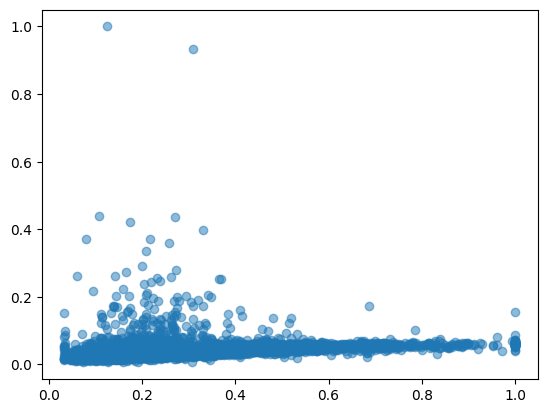

In [155]:
plt.scatter(DataFrame_taken[features_taken[0]], DataFrame_taken[features_taken[1]], alpha= 0.5)

In [156]:
Model = logisticRegression(x_train, y_train)

In [157]:
Model.fit()

Epoch 1


NameError: name 'train_y' is not defined